# Naive Bayes para clasificación de sentimientos
**Alejandro Abril — Parte 1**

Mi aporte es comparar MultinomialNB y ComplementNB con BoW y TF-IDF. La versión anterior con cláusulas llegó a 87,61% en CV y 87,71% en validación. Aquí la vuelvo a entrenar como referencia y pruebo ajustes que salen del material de 202620.

La meta es intentar llegar al 90% en Kaggle. Esa cifra se confirma con un envío real; las métricas de este notebook son evaluaciones locales. Mantengo los resultados, los errores y la explicación del proceso en estas celdas.

## 1. Qué tomé del curso

Revisé P1–P10 y los laboratorios de 202620. Para este problema de clasificación de texto, estos son los puntos que uso:

| Decisión | Fuente de 202620 | Aplicación aquí |
|---|---|---|
| Revisar completitud, unicidad, consistencia y validez | P1, sección 6; P2, sección 3 | Textos, etiquetas e IDs; excluir registros sin texto o etiqueta y detectar duplicados |
| Crear características a partir del problema | P2, sección 4.3 | Conservar las marcas de cláusulas del equipo; explicar su propósito |
| Conservar negaciones, usar palabras y bigramas | P3, secciones 2.3–2.5; ejercicios 1 y 3 | Comparar unigramas y bigramas; mantener “no”, “pero” y los acentos |
| Comparar conteos, presencia binaria y TF-IDF | P3, secciones 3.2 y 4; ejercicio 6 | Probar conteo binario y TF logarítmico |
| Mantener la preparación dentro del pipeline | P4, sección 5; P7, sección 6 | Aprender vocabulario e IDF únicamente con el entrenamiento de cada fold |
| Buscar parámetros y evaluar todo el proceso | P7, secciones 7, 8 y 10 | GridSearchCV, métricas por clase y CV anidada de cinco por cinco particiones |
| Interpretar la pérdida de características | P8, ejercicio 1 | Retirar un bloque a la vez, conservando los otros parámetros para aislar su aporte |
| Comparar desempeño, complejidad y variación | Laboratorio 2, actividades 2, 5 y 6 | Promedio y desviación de CV, brecha train/CV y bootstrap descriptivo |
| Guardar el pipeline completo | P7, sección 9 | joblib y comprobación de las predicciones al recargar |

P3, ejercicio 3, propone explícitamente probar Naive Bayes con bigramas. Los detalles de MultinomialNB y ComplementNB se apoyan en la documentación oficial de scikit-learn.

Las marcas de cláusulas y los n-gramas de caracteres son adaptaciones del proyecto tomadas del equipo, no ejemplos copiados de P3. Se mantienen las funciones publicadas en transformaciones.py. La unión de los bloques se hace con FeatureUnion.

Las prácticas P5/P6 y L1 ayudan a discutir complejidad y generalización, aunque sus modelos de regresión no corresponden a estas tres etiquetas. P9/P10 aportan la revisión de fuga de datos y métricas por clase; las proporciones de las clases son cercanas, así que aquí no se generan muestras con SMOTE.

## 2. Entorno

Uso Python 3.12 y las versiones de requirements.txt del equipo. Para ejecutar: crear el entorno, instalar ese archivo, seleccionar su kernel y correr las celdas en orden desde el proyecto o notebooks/.

Los datos van en data/. La búsqueda usa dos procesos, guarda su caché en una carpeta temporal del sistema y la elimina al terminar. La CV anidada repite la búsqueda cinco veces y tarda bastante más que la comparación inicial. Si hace falta, N_JOBS puede ponerse en 1.

In [1]:
import sys
import platform
from pathlib import Path
from tempfile import TemporaryDirectory

import numpy as np
import pandas as pd
import sklearn
import scipy
import joblib
import nltk
from joblib import Memory
from IPython.display import display, HTML, Markdown
from sklearn.base import clone
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.preprocessing import FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, ParameterGrid, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

if sys.version_info[:2] != (3, 12) or sklearn.__version__ != "1.9.0":
    raise RuntimeError("Selecciona el entorno del equipo: Python 3.12 y scikit-learn 1.9.0.")

RAIZ = next((p for p in [Path.cwd(), Path.cwd().parent] if (p / "notebooks/04_Naive_Bayes.ipynb").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Ejecuta desde la carpeta del proyecto o desde notebooks/.")
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))
from transformaciones import preparar_textos_nb, extraer_oraciones_lote, marcar_conectores_lote, marcar_clausulas_lote

SEMILLA = 42
N_FOLDS = 5
N_JOBS = 2
versiones = {"python": platform.python_version(), "scikit-learn": sklearn.__version__,
            "numpy": np.__version__, "pandas": pd.__version__, "scipy": scipy.__version__,
            "joblib": joblib.__version__, "nltk": nltk.__version__}
print(versiones)
from itertools import product
from time import perf_counter
from sklearn.model_selection import cross_validate

{'python': '3.12.14', 'scikit-learn': '1.9.0', 'numpy': '2.5.3', 'pandas': '3.0.6', 'scipy': '1.18.1', 'joblib': '1.6.0', 'nltk': '3.10.3'}


## 3. Revisar los datos

Las revisiones siguen las dimensiones de calidad de P1/P2. No uso el ID como característica. Un texto duplicado en entrenamiento y validación puede inflar el resultado, así que lo reviso antes de separar. Si una reseña tiene etiquetas contradictorias, la ejecución se detiene para poder revisar el caso.

In [2]:
candidatas = [Path.cwd(), Path.cwd().parent]
RAIZ = next((p for p in candidatas if (p / "notebooks/04_Naive_Bayes.ipynb").is_file()), None)
if RAIZ is None:
    raise FileNotFoundError("Ejecuta desde la raíz del proyecto o desde notebooks/.")
DATA_DIR = RAIZ / "data"
ruta_train = DATA_DIR / "train.csv"
if not ruta_train.is_file():
    raise FileNotFoundError(f"Falta {ruta_train}. Descarga el train.csv de la competencia.")

CLASES = ["negativo", "neutral", "positivo"]

def validar_datos_train(datos):
    faltantes = {"id", "text", "label"} - set(datos.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas en train.csv: {sorted(faltantes)}")
    if datos["id"].isna().any() or datos["id"].duplicated().any():
        raise ValueError("train.csv contiene identificadores vacíos o repetidos.")
    datos = datos.copy()
    textos = datos["text"].astype("string")
    etiquetas = datos["label"].astype("string")
    validos = textos.notna() & textos.str.strip().ne("") & etiquetas.notna() & etiquetas.str.strip().ne("")
    limpieza = {"filas_originales": len(datos), "filas_vacias_excluidas": int((~validos).sum())}
    datos = datos.loc[validos].copy()
    if not datos["text"].map(lambda x: isinstance(x, str)).all():
        raise ValueError("Los textos deben ser cadenas de caracteres.")
    if set(datos["label"].unique()) != set(CLASES):
        raise ValueError(f"Se esperan las tres etiquetas exactas {CLASES}. Revisa train.csv.")
    claves = datos["text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
    etiquetas_por_texto = datos.groupby(claves)["label"].nunique()
    if (etiquetas_por_texto > 1).any():
        raise ValueError("Hay reseñas repetidas con etiquetas contradictorias. Revisa los datos.")
    repetidos = claves.duplicated()
    limpieza["textos_repetidos_excluidos"] = int(repetidos.sum())
    datos = datos.loc[~repetidos].reset_index(drop=True)
    if datos["label"].value_counts().min() < 10:
        raise ValueError("Se necesitan al menos 10 textos distintos por clase para esta partición y CV.")
    limpieza["filas_utilizadas"] = len(datos)
    return datos, limpieza

train, limpieza = validar_datos_train(pd.read_csv(ruta_train))
print(limpieza)
display(train.head())
display(train["label"].value_counts().reindex(CLASES))

{'filas_originales': 12000, 'filas_vacias_excluidas': 0, 'textos_repetidos_excluidos': 0, 'filas_utilizadas': 12000}


,id,text,label
0,0,Lo pedí un martes por la noche y me llegó al d...,neutral
1,1,Se lo compré a un familiar después de pensarla...,positivo
2,2,Lo pedí a mediados de mes y me llegó en tres d...,negativo
3,3,Compré esto en línea y llegó en unos tres días...,negativo
4,4,Compré este kit el mes pasado porque necesitab...,positivo


label
negativo    4212
neutral     3576
positivo    4212
Name: count, dtype: int64

## 4. División y evaluación

Mantengo 80/20, estratificación y semilla 42 para comparar con el grupo. Dentro del 80% hago las búsquedas con cinco folds, también estratificados y con semilla 42.

El 20% ya se consultó en versiones anteriores. Lo reporto como comparación complementaria. Para medir el proceso de selección, la CV anidada vuelve a ejecutar las dos etapas de búsqueda dentro del entrenamiento de cada fold externo. eval.csv se lee únicamente después de elegir el modelo, al generar el archivo de Kaggle.

La accuracy es la métrica principal de la competencia. F1 macro permite comprobar que la mejora no se obtiene sacrificando una de las tres clases.

In [3]:
# P7, secciones 5 y 7: separación de datos y validación estratificada.
# Aquí usamos 80/20, semilla 42 y cinco particiones para el experimento del grupo.
X_train, X_val, y_train, y_val = train_test_split(
    train["text"], train["label"], test_size=0.20, random_state=SEMILLA, stratify=train["label"]
)
if y_train.value_counts().min() < N_FOLDS:
    raise ValueError("No hay suficientes ejemplos por clase para cinco folds.")
cv = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA).split(X_train, y_train))
distribucion = pd.concat([
    y_train.value_counts(normalize=True).rename("entrenamiento"),
    y_val.value_counts(normalize=True).rename("validación_reservada"),
], axis=1).reindex(CLASES)
print(f"Entrenamiento: {len(X_train)} · Validación reservada: {len(X_val)}")
display((100 * distribucion).round(2))

Entrenamiento: 9600 · Validación reservada: 2400


,entrenamiento,validación_reservada
label,,
negativo,35.09,35.12
neutral,29.80,29.79
positivo,35.10,35.08


## 5. Qué hace Naive Bayes

MultinomialNB suma, para cada clase, el logaritmo de su probabilidad previa y las contribuciones de los términos del texto: log P(clase) + suma de x_j · log P(término_j | clase). Predice la clase con mayor puntuación. El supuesto de independencia condicional simplifica el cálculo, pero palabras como “no funciona” están relacionadas entre sí.

Con conteos, el suavizado estima P(término_j | clase) = (conteo_j + alpha) / (conteos totales + alpha · tamaño del vocabulario). Así un término que no apareció en una clase no anula toda su puntuación. Un alpha muy pequeño puede dar demasiado peso a términos raros; uno muy grande puede borrar diferencias útiles.

TF-IDF usa pesos en lugar de conteos enteros: la puntuación sigue siendo computable, aunque deja de ser una interpretación literal de conteos multinomiales. El TF logarítmico reduce el efecto de repetir una palabra. La representación binaria solo registra si apareció.

ComplementNB estima sus pesos usando los textos de las otras clases. Puede ayudar con clases desbalanceadas, pero su ventaja se debe medir. Mantengo fit_prior=True en MultinomialNB y norm=False en ComplementNB, como en la comparación anterior.

El pipeline tiene cuatro bloques: contexto por cláusulas, texto completo, palabras finales y caracteres finales. Las marcas incorporan conector y posición; los caracteres permiten compartir fragmentos entre formas de una palabra. Todos producen características dispersas y no negativas.

In [4]:
ejemplo = "El sonido es excelente, pero la conexión es lenta. Eso sí, la batería funciona bien."
display(pd.DataFrame({
    "representación": ["Texto", "Stemming", "Última oración", "Conectores", "Cláusulas"],
    "resultado": [ejemplo, preparar_textos_nb([ejemplo])[0],
                  extraer_oraciones_lote([ejemplo])[0],
                  marcar_conectores_lote([ejemplo], palabras_conector=1)[0],
                  marcar_clausulas_lote([ejemplo], palabras_conector=1)[0]],
}))

,representación,resultado
0,Texto,"El sonido es excelente, pero la conexión es le..."
1,Stemming,el son es excelent pero la conexion es lent es...
2,Última oración,"Eso sí, la batería funciona bien."
3,Conectores,el__el el__sonido el__es el__excelente el__per...
4,Cláusulas,el__el el__sonido el__es el__excelente p3__el ...


## 6. Dos etapas de búsqueda

La primera etapa compara las cuatro familias. Prueba alpha = 0.01, 0.03, 0.1, 0.3 y 1; unigramas o unigramas con bigramas en los bloques de palabras; y min_df = 1, 2 o 3 en los cuatro bloques. Son 120 configuraciones.

La segunda toma el mejor candidato de cada familia y refina los dos que quedaron arriba. Conserva el alpha, min_df y los n-gramas elegidos; prueba conteo binario o TF logarítmico, una o dos palabras de conector, una o dos oraciones finales y cuatro esquemas de pesos. Son 64 configuraciones.

En ambos pasos, todos los candidatos usan los mismos folds. El desempate es accuracy, F1 macro y menor desviación, en ese orden. Si todo coincide, se conserva el primer candidato para que la selección sea reproducible. La referencia anterior también se puede recuperar en la primera rejilla.

In [5]:
FAMILIAS = [("BoW", "MultinomialNB"), ("BoW", "ComplementNB"),
            ("TF-IDF", "MultinomialNB"), ("TF-IDF", "ComplementNB")]
ALPHAS = [0.01, 0.03, 0.1, 0.3, 1.0]
SCORING = {"accuracy": "accuracy", "f1_macro": "f1_macro"}
BLOQUES = ["contexto", "texto", "ultima_palabras", "ultima_caracteres"]

def vectorizador(tipo, contexto=False, caracteres=False):
    clase = CountVectorizer if tipo == "BoW" else TfidfVectorizer
    opciones = dict(min_df=2, lowercase=True, strip_accents=None)
    if contexto:
        opciones.update(token_pattern=r"\S+", lowercase=False, ngram_range=(1, 1))
    elif caracteres:
        opciones.update(analyzer="char", ngram_range=(3, 5))
    else:
        opciones["ngram_range"] = (1, 2)
    if tipo == "TF-IDF":
        opciones["sublinear_tf"] = True
    return clase(**opciones)

def bloque_final(tipo, caracteres=False):
    return Pipeline([
        ("extraer", FunctionTransformer(extraer_oraciones_lote, kw_args={"cantidad": 1}, validate=False)),
        ("vector", vectorizador(tipo, caracteres=caracteres)),
    ])

def crear_pipeline(tipo, modelo):
    representacion = FeatureUnion([
        ("contexto", Pipeline([
            ("marcar", FunctionTransformer(marcar_clausulas_lote, kw_args={"palabras_conector": 1}, validate=False)),
            ("vector", vectorizador(tipo, contexto=True)),
        ])),
        ("texto", vectorizador(tipo)),
        ("ultima_palabras", bloque_final(tipo)),
        ("ultima_caracteres", bloque_final(tipo, caracteres=True)),
    ])
    clasificador = MultinomialNB() if modelo == "MultinomialNB" else ComplementNB()
    return Pipeline([("representacion", representacion), ("classifier", clasificador)])

VECTORES = ["representacion__contexto__vector", "representacion__texto",
            "representacion__ultima_palabras__vector", "representacion__ultima_caracteres__vector"]

def rejilla_inicial():
    rejillas = []
    for ngramas, min_df in product([(1, 1), (1, 2)], [1, 2, 3]):
        rejilla = {"classifier__alpha": ALPHAS}
        rejilla.update({nombre + "__min_df": [min_df] for nombre in VECTORES})
        rejilla["representacion__texto__ngram_range"] = [ngramas]
        rejilla["representacion__ultima_palabras__vector__ngram_range"] = [ngramas]
        rejillas.append(rejilla)
    return rejillas

def rejilla_refinamiento(tipo):
    pesos = [None,
             dict(contexto=2, texto=1, ultima_palabras=1, ultima_caracteres=1),
             dict(contexto=1, texto=2, ultima_palabras=1, ultima_caracteres=1),
             dict(contexto=1, texto=1, ultima_palabras=2, ultima_caracteres=2)]
    rejilla = {
        "representacion__contexto__marcar__kw_args": [{"palabras_conector": 1}, {"palabras_conector": 2}],
        "representacion__ultima_palabras__extraer__kw_args": [{"cantidad": 1}, {"cantidad": 2}],
        "representacion__transformer_weights": pesos,
    }
    # Las dos vistas finales deben recibir las mismas oraciones.
    rejillas = []
    opcion = "__binary" if tipo == "BoW" else "__sublinear_tf"
    for cantidad in [1, 2]:
        parte = {k: v for k, v in rejilla.items() if k != "representacion__ultima_palabras__extraer__kw_args"}
        parte["representacion__ultima_palabras__extraer__kw_args"] = [{"cantidad": cantidad}]
        parte["representacion__ultima_caracteres__extraer__kw_args"] = [{"cantidad": cantidad}]
        # Una misma regla de frecuencia se aplica a los cuatro bloques.
        for valor in [False, True]:
            variante = dict(parte)
            variante.update({nombre + opcion: [valor] for nombre in VECTORES})
            rejillas.append(variante)
    return rejillas

def ordenar(tabla):
    return tabla.sort_values(["accuracy_cv", "f1_macro_cv", "std_accuracy_cv"],
                             ascending=[False, False, True], kind="stable")

def elegir_indice(resultados):
    tabla = pd.DataFrame({
        "accuracy_cv": resultados["mean_test_accuracy"],
        "f1_macro_cv": resultados["mean_test_f1_macro"],
        "std_accuracy_cv": resultados["std_test_accuracy"],
    })
    return int(ordenar(tabla).index[0])

def buscar(pipeline, rejilla, X, y, folds, memoria, tipo, modelo, etapa):
    candidato = clone(pipeline)
    candidato.memory = memoria
    grid = GridSearchCV(candidato, rejilla, scoring=SCORING, refit=elegir_indice,
                        cv=folds, n_jobs=N_JOBS, pre_dispatch=N_JOBS,
                        error_score="raise", return_train_score=True)
    print(f"{etapa}: {tipo} + {modelo}, {len(ParameterGrid(rejilla))} configuraciones", flush=True)
    grid.fit(X, y)
    tabla = pd.DataFrame({
        "vectorizador": tipo, "modelo": modelo, "etapa": etapa,
        "accuracy_cv": grid.cv_results_["mean_test_accuracy"],
        "f1_macro_cv": grid.cv_results_["mean_test_f1_macro"],
        "std_accuracy_cv": grid.cv_results_["std_test_accuracy"],
        "accuracy_train_cv": grid.cv_results_["mean_train_accuracy"],
        "parametros": grid.cv_results_["params"],
    })
    tabla["brecha_train_cv"] = tabla["accuracy_train_cv"] - tabla["accuracy_cv"]
    mejor = grid.best_estimator_
    mejor.memory = None
    fila = tabla.iloc[grid.best_index_].to_dict()
    print(f"  Mejor: {fila['accuracy_cv']:.4f}; F1 macro: {fila['f1_macro_cv']:.4f}", flush=True)
    return mejor, tabla, fila

def buscar_dos_etapas(X, y, folds, memoria):
    tablas, filas, candidatos = [], [], {}
    for tipo, modelo in FAMILIAS:
        pipe, tabla, fila = buscar(crear_pipeline(tipo, modelo), rejilla_inicial(),
                                   X, y, folds, memoria, tipo, modelo, "inicial")
        clave = f"{tipo} / {modelo} / inicial"
        tablas.append(tabla)
        filas.append({**fila, "clave": clave})
        candidatos[clave] = pipe
    iniciales = ordenar(pd.DataFrame(filas)).head(2).copy()
    for _, inicial in iniciales.iterrows():
        tipo, modelo = inicial["vectorizador"], inicial["modelo"]
        pipe, tabla, fila = buscar(candidatos[inicial["clave"]], rejilla_refinamiento(tipo),
                                   X, y, folds, memoria, tipo, modelo, "refinamiento")
        clave = f"{tipo} / {modelo} / refinamiento"
        tablas.append(tabla)
        filas.append({**fila, "clave": clave})
        candidatos[clave] = pipe
    finalistas = ordenar(pd.DataFrame(filas))
    ganador = finalistas.iloc[0]
    return candidatos[ganador["clave"]], ganador, pd.concat(tablas, ignore_index=True), finalistas, candidatos

## 7. Comparación con la referencia

Vuelvo a ajustar la configuración anterior con las mismas cinco particiones. Este pipeline se entrena únicamente con X_train: no cargo el modelo que ya vio las 12.000 etiquetas para evaluar las reseñas reservadas.

Después ejecuto las dos etapas. La caché se comparte entre las cuatro familias para reutilizar una representación cuando solo cambia el clasificador.

In [6]:
with TemporaryDirectory(prefix="nb-202620-") as carpeta_cache:
    memoria = Memory(carpeta_cache, verbose=0)
    anterior = crear_pipeline("TF-IDF", "MultinomialNB").set_params(classifier__alpha=0.1)
    referencia, tabla_referencia, fila_referencia = buscar(
        anterior, {}, X_train, y_train, cv, memoria, "TF-IDF", "MultinomialNB", "referencia_anterior")
    mejor_modelo, mejor_resultado, tabla_experimentos, tabla_finalistas, candidatos = buscar_dos_etapas(
        X_train, y_train, cv, memoria)

print("Elegido por CV:", mejor_resultado["clave"])
print("Parámetros completos:", mejor_modelo.get_params(deep=False))

referencia_anterior: TF-IDF + MultinomialNB, 1 configuraciones
  Mejor: 0.8761; F1 macro: 0.8801
inicial: BoW + MultinomialNB, 30 configuraciones
  Mejor: 0.8708; F1 macro: 0.8754
inicial: BoW + ComplementNB, 30 configuraciones
  Mejor: 0.8453; F1 macro: 0.8459
inicial: TF-IDF + MultinomialNB, 30 configuraciones
  Mejor: 0.8781; F1 macro: 0.8820
inicial: TF-IDF + ComplementNB, 30 configuraciones
  Mejor: 0.8589; F1 macro: 0.8607
refinamiento: TF-IDF + MultinomialNB, 32 configuraciones
  Mejor: 0.8781; F1 macro: 0.8820
refinamiento: BoW + MultinomialNB, 32 configuraciones
  Mejor: 0.8730; F1 macro: 0.8775
Elegido por CV: TF-IDF / MultinomialNB / inicial
Parámetros completos: {'memory': None, 'steps': [('representacion', FeatureUnion(transformer_list=[('contexto',
                                Pipeline(steps=[('marcar',
                                                 FunctionTransformer(func=<function marcar_clausulas_lote at 0x111caaa20>,
                                             

## 8. Resultados de la búsqueda

La primera tabla compara las cuatro familias. La segunda muestra las dos etapas y la referencia. Las métricas de búsqueda sirven para elegir los parámetros; la CV anidada de la sección siguiente estima el procedimiento completo.

La brecha entre accuracy de entrenamiento y CV ayuda a detectar memorización. La desviación entre folds expresa variación, no una garantía de mejora.

In [7]:
por_familia = tabla_finalistas.drop_duplicates(["vectorizador", "modelo"]).copy()
columnas = ["vectorizador", "modelo", "etapa", "accuracy_cv", "f1_macro_cv", "std_accuracy_cv", "brecha_train_cv"]
por_familia["alpha"] = [candidatos[k]["classifier"].alpha for k in por_familia["clave"]]
por_familia["n_gramas"] = [candidatos[k].get_params()["representacion__texto__ngram_range"] for k in por_familia["clave"]]
por_familia["min_df"] = [candidatos[k].get_params()["representacion__texto__min_df"] for k in por_familia["clave"]]
columnas_familias = ["vectorizador", "modelo", "etapa", "alpha", "n_gramas", "min_df",
                    "accuracy_cv", "f1_macro_cv", "std_accuracy_cv", "brecha_train_cv"]
display(por_familia[columnas_familias].round(4))
evolucion = pd.concat([tabla_referencia, tabla_finalistas], ignore_index=True)
display(evolucion[columnas].round(4))
display(HTML(f"<details><summary>Ver las {len(tabla_experimentos)} configuraciones nuevas</summary>"
             + ordenar(tabla_experimentos).round(4).to_html(index=False) + "</details>"))
parametros_elegidos = {
    "modelo": mejor_resultado["modelo"], "representación": mejor_resultado["vectorizador"],
    "alpha": mejor_modelo["classifier"].alpha,
    "n_gramas": mejor_modelo.get_params()["representacion__texto__ngram_range"],
    "min_df": mejor_modelo.get_params()["representacion__texto__min_df"],
    "palabras_conector": mejor_modelo.get_params()["representacion__contexto__marcar__kw_args"]["palabras_conector"],
    "oraciones_finales": mejor_modelo.get_params()["representacion__ultima_palabras__extraer__kw_args"]["cantidad"],
    "pesos_bloques": mejor_modelo["representacion"].transformer_weights,
}
display(pd.DataFrame([parametros_elegidos]))
display(Markdown(
    f"La referencia vuelve a dar **{100*fila_referencia['accuracy_cv']:.2f}%** en CV. "
    f"La búsqueda eligió **{mejor_resultado['vectorizador']} + {mejor_resultado['modelo']}**, "
    f"con **{100*mejor_resultado['accuracy_cv']:.2f}%**. "
    f"La diferencia es de **{100*(mejor_resultado['accuracy_cv']-fila_referencia['accuracy_cv']):.2f} puntos**. "
    "La selección consideró accuracy, F1 macro y desviación; todavía falta la evaluación externa del proceso."
))

,vectorizador,modelo,etapa,alpha,n_gramas,min_df,accuracy_cv,f1_macro_cv,std_accuracy_cv,brecha_train_cv
0,TF-IDF,MultinomialNB,inicial,0.10,"(1, 2)",1,0.8781,0.8820,0.0112,0.0928
1,BoW,MultinomialNB,refinamiento,0.10,"(1, 2)",1,0.8730,0.8775,0.0113,0.1056
2,TF-IDF,ComplementNB,inicial,1.00,"(1, 2)",1,0.8589,0.8607,0.0140,0.0626
3,BoW,ComplementNB,inicial,0.01,"(1, 2)",3,0.8453,0.8459,0.0111,0.0782


,vectorizador,modelo,etapa,accuracy_cv,f1_macro_cv,std_accuracy_cv,brecha_train_cv
0,TF-IDF,MultinomialNB,referencia_anterior,0.8761,0.8801,0.0121,0.0779
1,TF-IDF,MultinomialNB,inicial,0.8781,0.8820,0.0112,0.0928
2,TF-IDF,MultinomialNB,refinamiento,0.8781,0.8820,0.0112,0.0928
3,BoW,MultinomialNB,refinamiento,0.8730,0.8775,0.0113,0.1056
4,BoW,MultinomialNB,inicial,0.8708,0.8754,0.0105,0.1071
5,TF-IDF,ComplementNB,inicial,0.8589,0.8607,0.0140,0.0626
6,BoW,ComplementNB,inicial,0.8453,0.8459,0.0111,0.0782


vectorizador,modelo,etapa,accuracy_cv,f1_macro_cv,std_accuracy_cv,accuracy_train_cv,parametros,brecha_train_cv
TF-IDF,MultinomialNB,inicial,0.8781,0.8820,0.0112,0.9710,"{'classifier__alpha': 0.1, 'representacion__contexto__vector__min_df': 1, 'representacion__texto__min_df': 1, 'representacion__texto__ngram_range': (1, 2), 'representacion__ultima_caracteres__vector__min_df': 1, 'representacion__ultima_palabras__vector__min_df': 1, 'representacion__ultima_palabras__vector__ngram_range': (1, 2)}",0.0928
TF-IDF,MultinomialNB,refinamiento,0.8781,0.8820,0.0112,0.9710,"{'representacion__contexto__marcar__kw_args': {'palabras_conector': 1}, 'representacion__contexto__vector__sublinear_tf': True, 'representacion__texto__sublinear_tf': True, 'representacion__transformer_weights': None, 'representacion__ultima_caracteres__extraer__kw_args': {'cantidad': 1}, 'representacion__ultima_caracteres__vector__sublinear_tf': True, 'representacion__ultima_palabras__extraer__kw_args': {'cantidad': 1}, 'representacion__ultima_palabras__vector__sublinear_tf': True}",0.0928
TF-IDF,MultinomialNB,refinamiento,0.8775,0.8814,0.0112,0.9705,"{'representacion__contexto__marcar__kw_args': {'palabras_conector': 1}, 'representacion__contexto__vector__sublinear_tf': False, 'representacion__texto__sublinear_tf': False, 'representacion__transformer_weights': None, 'representacion__ultima_caracteres__extraer__kw_args': {'cantidad': 1}, 'representacion__ultima_caracteres__vector__sublinear_tf': False, 'representacion__ultima_palabras__extraer__kw_args': {'cantidad': 1}, 'representacion__ultima_palabras__vector__sublinear_tf': False}",0.0930
TF-IDF,MultinomialNB,refinamiento,0.8772,0.8818,0.0100,0.9843,"{'representacion__contexto__marcar__kw_args': {'palabras_conector': 1}, 'representacion__contexto__vector__sublinear_tf': False, 'representacion__texto__sublinear_tf': False, 'representacion__transformer_weights': {'contexto': 2, 'texto': 1, 'ultima_palabras': 1, 'ultima_caracteres': 1}, 'representacion__ultima_caracteres__extraer__kw_args': {'cantidad': 1}, 'representacion__ultima_caracteres__vector__sublinear_tf': False, 'representacion__ultima_palabras__extraer__kw_args': {'cantidad': 1}, 'representacion__ultima_palabras__vector__sublinear_tf': False}",0.1071
TF-IDF,MultinomialNB,refinamiento,0.8771,0.8817,0.0098,0.9846,"{'representacion__contexto__marcar__kw_args': {'palabras_conector': 1}, 'representacion__contexto__vector__sublinear_tf': True, 'representacion__texto__sublinear_tf': True, 'representacion__transformer_weights': {'contexto': 2, 'texto': 1, 'ultima_palabras': 1, 'ultima_caracteres': 1}, 'representacion__ultima_caracteres__extraer__kw_args': {'cantidad': 1}, 'representacion__ultima_caracteres__vector__sublinear_tf': True, 'representacion__ultima_palabras__extraer__kw_args': {'cantidad': 1}, 'representacion__ultima_palabras__vector__sublinear_tf': True}",0.1076
TF-IDF,MultinomialNB,inicial,0.8766,0.8808,0.0077,0.9830,"{'classifier__alpha': 0.03, 'representacion__contexto__vector__min_df': 1, 'representacion__texto__min_df': 1, 'representacion__texto__ngram_range': (1, 2), 'representacion__ultima_caracteres__vector__min_df': 1, 'representacion__ultima_palabras__vector__min_df': 1, 'representacion__ultima_palabras__vector__ngram_range': (1, 2)}",0.1065
TF-IDF,MultinomialNB,inicial,0.8765,0.8804,0.0128,0.9541,"{'classifier__alpha': 0.3, 'representacion__contexto__vector__min_df': 1, 'representacion__texto__min_df': 1, 'representacion__texto__ngram_range': (1, 2), 'representacion__ultima_caracteres__vector__min_df': 1, 'representacion__ultima_palabras__vector__min_df': 1, 'representacion__ultima_palabras__vector__ngram_range': (1, 2)}",0.0776
TF-IDF,MultinomialNB,inicial,0.8761,0.8801,0.0121,0.9540,"{'classifier__alpha': 0.1, 'representacion__contexto__vector__min_df': 2, 'representacion__texto__min_df': 2, 'representacion__texto__ngram_range': (1, 2), 'representacion__ultima_caracteres__vector__min_df': 2, 'representacion__ultima_palabras__vector__min_df

,modelo,representación,alpha,n_gramas,min_df,palabras_conector,oraciones_finales,pesos_bloques
0,MultinomialNB,TF-IDF,0.1,"(1, 2)",1,1,1,None


La referencia vuelve a dar **87.61%** en CV. La búsqueda eligió **TF-IDF + MultinomialNB**, con **87.81%**. La diferencia es de **0.20 puntos**. La selección consideró accuracy, F1 macro y desviación; todavía falta la evaluación externa del proceso.

## 9. CV anidada, como en P7

Hay cinco particiones externas sobre X_train. En cada una, el 80% externo pasa por la búsqueda inicial de las cuatro familias y el refinamiento de los dos mejores candidatos, usando cinco particiones internas nuevas. La configuración seleccionada predice el 20% externo después de terminar la búsqueda.

No se usan los finalistas de la búsqueda global como atajo: los dos candidatos se eligen otra vez en cada fold externo. También entreno la referencia fija en el mismo entrenamiento externo para comparar en las mismas reseñas.

Esta estimación corresponde a la receta de búsqueda fijada para esta versión. La representación se diseñó en iteraciones anteriores con este mismo conjunto de datos, por lo que sigue siendo necesario comprobar el resultado en Kaggle.

In [8]:
filas_anidadas = []
for numero, (indices_train, indices_test) in enumerate(cv, start=1):
    inicio = perf_counter()
    X_interno, y_interno = X_train.iloc[indices_train], y_train.iloc[indices_train]
    X_externo, y_externo = X_train.iloc[indices_test], y_train.iloc[indices_test]
    folds_internos = list(StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEMILLA).split(X_interno, y_interno))
    print(f"\nFold externo {numero}/{N_FOLDS}: se repiten ambas búsquedas", flush=True)
    with TemporaryDirectory(prefix=f"nb-anidada-{numero}-") as carpeta_cache:
        ganador, resultado, tabla, _, _ = buscar_dos_etapas(
            X_interno, y_interno, folds_internos, Memory(carpeta_cache, verbose=0))
    pred = ganador.predict(X_externo)
    ref_externa = clone(referencia).fit(X_interno, y_interno)
    accuracy_ref = accuracy_score(y_externo, ref_externa.predict(X_externo))
    filas_anidadas.append({
        "fold": numero, "accuracy_externa": accuracy_score(y_externo, pred),
        "f1_macro_externo": f1_score(y_externo, pred, average="macro"),
        "accuracy_referencia": accuracy_ref,
        "accuracy_seleccion_interna": resultado["accuracy_cv"],
        "ganador": resultado["clave"], "parametros": resultado["parametros"],
        "configuraciones": len(tabla), "segundos": perf_counter() - inicio,
    })
    print(f"Resultado externo: {filas_anidadas[-1]['accuracy_externa']:.4f}", flush=True)

tabla_anidada = pd.DataFrame(filas_anidadas)
tabla_anidada["mejora_sobre_referencia"] = tabla_anidada["accuracy_externa"] - tabla_anidada["accuracy_referencia"]
accuracy_anidada = tabla_anidada["accuracy_externa"].mean()
std_anidada = tabla_anidada["accuracy_externa"].std(ddof=0)
display(tabla_anidada.round(4))
display(Markdown(
    f"La búsqueda completa obtuvo **{100*accuracy_anidada:.2f}% ± {100*std_anidada:.2f} puntos** "
    f"de accuracy externa, frente a **{100*tabla_anidada['accuracy_referencia'].mean():.2f}%** de la referencia. "
    "Comparo estos valores con la búsqueda global para revisar cuánto optimismo introduce la selección de parámetros. "
    "El signo ± corresponde a la desviación entre folds."
))


Fold externo 1/5: se repiten ambas búsquedas
inicial: BoW + MultinomialNB, 30 configuraciones
  Mejor: 0.8677; F1 macro: 0.8727
inicial: BoW + ComplementNB, 30 configuraciones
  Mejor: 0.8415; F1 macro: 0.8426
inicial: TF-IDF + MultinomialNB, 30 configuraciones
  Mejor: 0.8699; F1 macro: 0.8744
inicial: TF-IDF + ComplementNB, 30 configuraciones
  Mejor: 0.8513; F1 macro: 0.8528
refinamiento: TF-IDF + MultinomialNB, 32 configuraciones
  Mejor: 0.8716; F1 macro: 0.8765
refinamiento: BoW + MultinomialNB, 32 configuraciones
  Mejor: 0.8677; F1 macro: 0.8727
Resultado externo: 0.8760

Fold externo 2/5: se repiten ambas búsquedas
inicial: BoW + MultinomialNB, 30 configuraciones
  Mejor: 0.8711; F1 macro: 0.8754
inicial: BoW + ComplementNB, 30 configuraciones
  Mejor: 0.8444; F1 macro: 0.8452
inicial: TF-IDF + MultinomialNB, 30 configuraciones
  Mejor: 0.8777; F1 macro: 0.8817
inicial: TF-IDF + ComplementNB, 30 configuraciones
  Mejor: 0.8552; F1 macro: 0.8564
refinamiento: TF-IDF + Multinom

/Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:787: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/april/Uni/9 Semestre/Machine learning/Proyecto-Mach

,fold,accuracy_externa,f1_macro_externo,accuracy_referencia,accuracy_seleccion_interna,ganador,parametros,configuraciones,segundos,mejora_sobre_referencia
0,1,0.8760,0.8807,0.8823,0.8716,TF-IDF / MultinomialNB / refinamiento,{'representacion__contexto__marcar__kw_args': ...,184,703.4824,-0.0062
1,2,0.8672,0.8720,0.8635,0.8777,TF-IDF / MultinomialNB / inicial,"{'classifier__alpha': 0.03, 'representacion__c...",184,750.0324,0.0036
2,3,0.8875,0.8920,0.8917,0.8698,TF-IDF / MultinomialNB / inicial,"{'classifier__alpha': 0.01, 'representacion__c...",184,679.4864,-0.0042
3,4,0.8839,0.8873,0.8828,0.8686,TF-IDF / MultinomialNB / inicial,"{'classifier__alpha': 0.03, 'representacion__c...",184,750.8507,0.0010
4,5,0.8578,0.8629,0.8604,0.8732,TF-IDF / MultinomialNB / inicial,"{'classifier__alpha': 0.01, 'representacion__c...",184,717.2924,-0.0026


La búsqueda completa obtuvo **87.45% ± 1.09 puntos** de accuracy externa, frente a **87.61%** de la referencia. Comparo estos valores con la búsqueda global para revisar cuánto optimismo introduce la selección de parámetros. El signo ± corresponde a la desviación entre folds.

## 10. Qué aporta cada bloque

Retiro un bloque a la vez y vuelvo a entrenar en las cinco particiones. Los demás parámetros permanecen fijos. Si la accuracy cae, ese bloque estaba aportando información útil a esta combinación; si sube, puede estar agregando ruido o información repetida.

El bloque se elimina de FeatureUnion, incluida su parte del vocabulario. No se simula su eliminación poniendo el peso en cero. Esta prueba explica el candidato ya elegido y no abre otra ronda de selección basada en el 20% de validación.

,variante,accuracy_cv,f1_macro_cv,std_accuracy_cv,diferencia_puntos
0,Completo,0.8781,0.8820,0.0112,0.0000
1,Sin contexto,0.8649,0.8682,0.0104,-1.3229
2,Sin texto,0.8694,0.8723,0.0126,-0.8750
3,Sin ultima_palabras,0.8733,0.8780,0.0110,-0.4792
4,Sin ultima_caracteres,0.8700,0.8755,0.0084,-0.8125


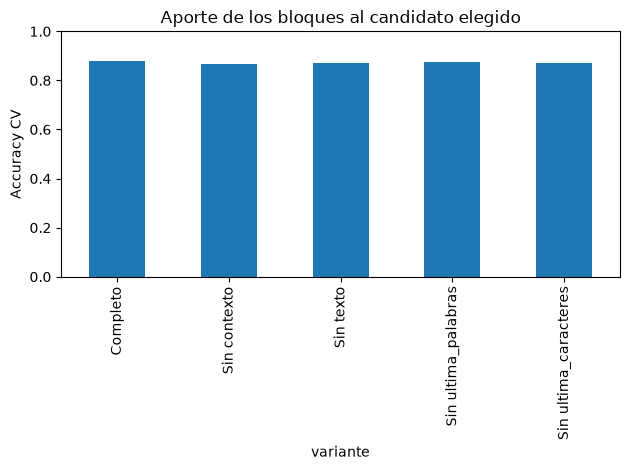

In [9]:
filas_componentes = []
for eliminado in [None] + BLOQUES:
    pipe = clone(mejor_modelo)
    union = pipe["representacion"]
    if eliminado is not None:
        union.transformer_list = [(nombre, bloque) for nombre, bloque in union.transformer_list if nombre != eliminado]
        if union.transformer_weights is not None:
            union.transformer_weights = {k: v for k, v in union.transformer_weights.items() if k != eliminado}
    resultados = cross_validate(pipe, X_train, y_train, cv=cv, scoring=SCORING,
                                n_jobs=N_JOBS, pre_dispatch=N_JOBS, error_score="raise")
    filas_componentes.append({
        "variante": "Completo" if eliminado is None else f"Sin {eliminado}",
        "accuracy_cv": resultados["test_accuracy"].mean(),
        "f1_macro_cv": resultados["test_f1_macro"].mean(),
        "std_accuracy_cv": resultados["test_accuracy"].std(),
    })
tabla_componentes = pd.DataFrame(filas_componentes)
tabla_componentes["diferencia_puntos"] = 100*(tabla_componentes["accuracy_cv"]-tabla_componentes.iloc[0]["accuracy_cv"])
display(tabla_componentes.round(4))
tabla_componentes.set_index("variante")["accuracy_cv"].plot.bar(
    ylim=(0, 1), ylabel="Accuracy CV", title="Aporte de los bloques al candidato elegido")
import matplotlib.pyplot as plt
plt.tight_layout()
plt.show()

## 11. Validación complementaria y errores

El modelo ya quedó elegido. Ahora comparo el candidato y la referencia en las mismas 2.400 reseñas reservadas. Leo la matriz por filas: qué etiqueta era realmente y cuál predijo.

El bootstrap de 500 remuestreos, adaptado de L2, muestra la variabilidad de accuracy y de su diferencia frente a la referencia. Es descriptivo de este conjunto reutilizado, no corrige la selección de modelos ni reemplaza la CV anidada.

Accuracy: 0.8771; F1 macro: 0.8814; referencia: 0.8771


,precision,recall,f1-score,support
negativo,0.8262,0.8458,0.8359,843.0000
neutral,0.9622,0.9972,0.9794,715.0000
positivo,0.8530,0.8064,0.8291,842.0000
accuracy,0.8771,0.8771,0.8771,0.8771
macro avg,0.8805,0.8831,0.8814,2400.0000
weighted avg,0.8761,0.8771,0.8762,2400.0000


Predicción,negativo,neutral,positivo
Real,,,
negativo,713,14,116
neutral,1,713,1
positivo,149,14,679


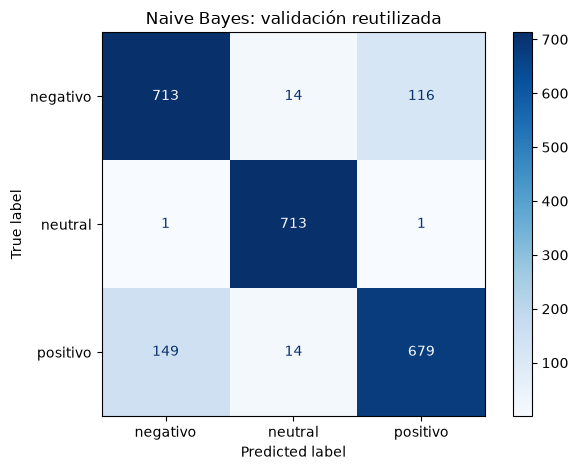

,id,texto,etiqueta_real,prediccion,prediccion_referencia
1532,1532,"Un comentario rapido. Compre esto en linea y llego en cuatro dias a mi casa, asi que nada que decir del envio. La verdad, la comodidad luce mal construida para lo que necesitaba, aunque al final la app del fabricante se sintio ligera para lo que cuesta.",positivo,negativo,negativo
11416,11416,"Lo pedí a mediados de marzo y me llegó en cuatro días, lo uso casi a diario para el gimnasio. El sistema de sonido me parece muy bueno, sin exagerar. La autonomía, en cambio, no me está funcionando nada bien. La carga apenas me rinde lo que esperaba, y eso que lo uso un par de horas. Tengo sentimientos encontrados con él, la verdad.",positivo,negativo,negativo
1647,1647,"Lo compré hace poco por internet y me llegó en tres días. Ya lo uso a diario en el trabajo. La funda no la recomiendo a nadie, la verdad. Eso sí, la terminación cumple de sobra. Tengo sentimientos encontrados con esto.",positivo,negativo,negativo
10361,10361,"Lo compre hace un par de semanas para el cuarto de mi mama y lo tengo funcionando sin parar desde entonces. Llego en tres dias, sin contratiemppos con el envio. La relacion calidad-precio me parecio torpe para lo que necesitaba, la verdad; sin embargo, la comodidad me resulto ligera desde el primer dia.",positivo,negativo,negativo
9687,9687,"La pedi a finales de mes y llego en unos cuatro dias a mi casa, con la caja bien cerrada. La pantalla tactil se ve practica en mi experiencia, la tengo en la entrada del departamento. Aun asi, la instalacion se sintio aparatosa para el precio que tiene, me tarde toda la tarde con mi cunado.",negativo,positivo,negativo
7988,7988,"Lo pedí en oferta hace unos meses y ya lleva un buen tiempo de uso acá en casa. La portabilidad se dañó antes de lo que esperaba, no duró casi nada esa parte. Por otro lado, la autonomía funciona de maravilla, la uso a diario para mis cosas. Así que ahí lo dejo, tal cual está.",positivo,negativo,positivo
3063,3063,"Me llego el martes pasado por la tarde, lo pedi un domingo y tardo dos dias. El menu de ajustes me decepciono de lo lindo. La uso a diario en la oficina, la compre con mi tarjeta del banco. Por otro lado, la comodidad esta por encima de la media. Sigo con dudas, la verdad.",positivo,negativo,negativo
10698,10698,"Lo comper a mediados de mes y llego en tres dias a mi casa. La nitidez de la imagen esta muy por debajo de la media. De paso, estoy feliz con el acabado. Queda a criterio de cada uno.",positivo,negativo,negativo


,percentil_2.5,percentil_97.5
accuracy,0.8644,0.8904
diferencia frente a referencia,-0.0042,0.0042


El candidato obtuvo **87.71%** en este 20%, con F1 macro **0.8814**. La referencia obtuvo **87.71%**. Quedaron **295 errores**: 116 negativos se confundieron con positivos y 149 positivos con negativos. Estas cifras permiten comprobar si la mejora se concentra en las opiniones opuestas.

In [10]:
predicciones_val = mejor_modelo.predict(X_val)
predicciones_ref = referencia.predict(X_val)
accuracy_val = accuracy_score(y_val, predicciones_val)
f1_val = f1_score(y_val, predicciones_val, average="macro")
accuracy_anterior = accuracy_score(y_val, predicciones_ref)
print(f"Accuracy: {accuracy_val:.4f}; F1 macro: {f1_val:.4f}; referencia: {accuracy_anterior:.4f}")
reporte = pd.DataFrame(classification_report(y_val, predicciones_val, labels=CLASES,
                                            output_dict=True, zero_division=0)).T
matriz = pd.DataFrame(confusion_matrix(y_val, predicciones_val, labels=CLASES),
                      index=pd.Index(CLASES, name="Real"), columns=pd.Index(CLASES, name="Predicción"))
display(reporte.round(4))
display(matriz)
ConfusionMatrixDisplay(matriz.to_numpy(), display_labels=CLASES).plot(cmap="Blues")
plt.title("Naive Bayes: validación reutilizada")
plt.tight_layout()
plt.show()
predicciones_validacion = pd.DataFrame({
    "id": train.loc[X_val.index, "id"], "texto": X_val, "etiqueta_real": y_val,
    "prediccion": predicciones_val, "prediccion_referencia": predicciones_ref,
})
errores = predicciones_validacion[predicciones_validacion["etiqueta_real"] != predicciones_validacion["prediccion"]]
with pd.option_context("display.max_colwidth", None):
    display(errores.sample(n=min(8, len(errores)), random_state=SEMILLA))
aciertos = np.asarray(y_val) == predicciones_val
aciertos_ref = np.asarray(y_val) == predicciones_ref
rng = np.random.default_rng(SEMILLA)
bootstrap = []
for _ in range(500):
    indices = rng.integers(0, len(y_val), size=len(y_val))
    bootstrap.append([aciertos[indices].mean(), (aciertos[indices].astype(float)-aciertos_ref[indices]).mean()])
intervalos = pd.DataFrame(np.quantile(bootstrap, [0.025, 0.975], axis=0).T,
                          index=["accuracy", "diferencia frente a referencia"],
                          columns=["percentil_2.5", "percentil_97.5"])
display(intervalos.round(4))
display(Markdown(
    f"El candidato obtuvo **{100*accuracy_val:.2f}%** en este 20%, con F1 macro **{f1_val:.4f}**. "
    f"La referencia obtuvo **{100*accuracy_anterior:.2f}%**. Quedaron **{len(errores)} errores**: "
    f"{matriz.loc['negativo','positivo']} negativos se confundieron con positivos y "
    f"{matriz.loc['positivo','negativo']} positivos con negativos. "
    "Estas cifras permiten comprobar si la mejora se concentra en las opiniones opuestas."
))

### Qué veo en estos errores

La clase neutral salió bien: se confundieron 2 de sus 715 reseñas. El problema está sobre todo entre positivo y negativo: esas dos direcciones suman 265 de los 295 errores. El recall positivo es 80,64%, menor que el negativo, de 84,58%. Por eso una mejora útil tendría que recuperar opiniones positivas con señales negativas, sin aumentar la confusión contraria.

En la reseña 1647, “no la recomiendo” se refiere a la funda, pero después aparece una valoración favorable de la terminación. La etiqueta es positiva y el modelo predice negativo. En la 7988 también hay dos opiniones opuestas: una parte se dañó y la autonomía funciona bien. Las marcas de cláusulas añaden contexto, pero Naive Bayes todavía suma evidencia de ambas partes y puede darle demasiado peso a la crítica. Estos ejemplos ayudan a entender la matriz; ocho casos no bastan para describir todos los errores.

El ajuste que ganó conserva términos que aparecen en una sola reseña del entrenamiento de cada fold (`min_df=1`, antes 2). Ganó 0,20 puntos en la búsqueda, pero el 20% quedó igual y el intervalo bootstrap de la diferencia va aproximadamente de −0,42 a +0,42 puntos. Incluye cero: con esta evaluación no puedo afirmar que el candidato supere a la referencia.

La CV anidada también pide cautela: dio 87,45% frente al 87,61% de la referencia fija. La brecha train/CV subió de 7,79 a 9,28 puntos al conservar términos raros. Es compatible con algo más de memorización; no demuestra por sí sola su causa. Mantengo el ganador de la regla acordada de selección, y el CSV de Kaggle permitirá comprobar su desempeño en datos externos.

Al retirar contexto se perdieron 1,32 puntos de CV; al retirar texto completo, 0,88; caracteres finales, 0,81; y palabras finales, 0,48. Todos aportaron a esta configuración. Duplicar pesos o ampliar el contexto no mejoró TF-IDF en esta búsqueda. Para una próxima iteración de Naive Bayes, tiene sentido revisar cómo representar la opinión que cambia después de un conector y controlar los términos raros, antes de agrandar otra vez la búsqueda de alpha.


### Mirar las características que inclinan la decisión

Para explicar el modelo, comparo los pesos de negativo y positivo y muestro los términos más distintos. Son asociaciones aprendidas, no reglas infalibles ni relaciones causales. Los nombres identifican el bloque del que viene cada término.

En MultinomialNB la diferencia corresponde al logaritmo de las probabilidades de los términos. En ComplementNB los valores internos son pesos derivados del complemento, así que su diferencia no se interpreta como un cociente literal de probabilidades.

In [11]:
clasificador = mejor_modelo["classifier"]
nombres = np.concatenate([
    np.array([f"{nombre}__{termino}" for termino in
              (bloque["vector"] if isinstance(bloque, Pipeline) else bloque).get_feature_names_out()])
    for nombre, bloque in mejor_modelo["representacion"].transformer_list
])
neg = list(clasificador.classes_).index("negativo")
pos = list(clasificador.classes_).index("positivo")
diferencia = clasificador.feature_log_prob_[pos] - clasificador.feature_log_prob_[neg]
indices = np.r_[np.argsort(diferencia)[:10], np.argsort(diferencia)[-10:][::-1]]
display(pd.DataFrame({"caracteristica": nombres[indices], "peso_positivo_menos_negativo": diferencia[indices]}).round(3))

,caracteristica,peso_positivo_menos_negativo
0,ultima_palabras__ordinaria,-4.465
1,ultima_palabras__floja,-4.409
2,ultima_palabras__chapucera,-4.364
3,ultima_palabras__defectuoso,-4.344
4,ultima_palabras__muy limitado,-4.300
5,ultima_palabras__limitado,-4.300
6,ultima_palabras__pésima,-4.290
7,ultima_palabras__mal hecha,-4.267
8,contexto__p1__pobre,-4.178
9,contexto__p1__torpe,-4.159


## 12. Evidencia para la rúbrica

Consulté las pestañas de [envíos](https://www.kaggle.com/competitions/parte-1-competencia-aprendizaje-de-maquina-2026-20/submissions) y [leaderboard público](https://www.kaggle.com/competitions/parte-1-competencia-aprendizaje-de-maquina-2026-20/leaderboard) de Kaggle el **10 de octubre de 2026**, con la sesión del equipo. Se ven ocho envíos completados: siete de modelos y uno del archivo de ejemplo. Los siete modelos de la tabla siguiente tienen estado Success y puntaje; cumplen el mínimo de cinco envíos distintos.

La línea base del leaderboard es **0,65555**. El equipo, **Grupo 21 Outliers del Sistema**, aparece en el puesto **33 de 41 filas clasificadas**, con un mejor puntaje de **0,88333**. Dos de las filas corresponden a cuentas eliminadas; esta posición y el cálculo aproximado siguiente son una fotografía del ranking público, no el percentil final de la evaluación.

Las búsquedas, la tabla de iteraciones y la eliminación de componentes explican el proceso de mejora. La teoría de Naive Bayes, las fuentes y los errores ayudan a sustentar las decisiones. La meta de 90% y superar el percentil 75 son criterios distintos: la rúbrica pide quedar por encima de aproximadamente tres cuartas partes de los equipos.

| Criterio de la rúbrica compartida | Evidencia en este trabajo |
|---|---|
| Número de envíos | Siete envíos de modelos con estado Success y puntaje en Kaggle |
| Proceso de mejora | Referencia reproducida, dos etapas de búsqueda y prueba de eliminación de bloques |
| Línea base | El mejor envío del grupo supera 0,65555; el envío de este Naive Bayes sigue pendiente |
| Organización | Datos, preparación, modelado, evaluación y exportación en secciones separadas |
| Sustentación y comprensión del modelo | Explicación de la puntuación, la independencia, alpha, BoW, TF-IDF y ComplementNB |
| Decisiones metodológicas | Fuentes de 202620, folds compartidos, selección por CV y evaluación anidada |
| Resultados | Métricas por clase, matriz, errores, comparación de componentes y variabilidad |
| Percentil | Puesto público registrado con fecha; la meta de superar el percentil 75 sigue pendiente |

No hay un envío de Naive Bayes en la lista consultada. Su puntaje se registrará después de subir el CSV de esta versión. El ranking público usa aproximadamente el 30% de las reseñas de evaluación; el resto corresponde al puntaje privado, así que la posición final puede cambiar.

In [12]:
BASELINE_KAGGLE = 0.65555
envios_grupo = pd.DataFrame([
    ("submission_regresion_logistica.csv", "Último 25% del texto; regresión logística", 0.83222),
    ("submission_regresion_logistica_v2.csv", "Última oración; palabras y caracteres", 0.86555),
    ("submission_svm_lineal_v2.csv", "Cambio de clasificador a SVM", 0.85666),
    ("submission_svm_lineal_conectores.csv", "Conectores y posición", 0.87555),
    ("submission_svm_lineal_clausulas.csv", "Cláusulas y contexto anterior", 0.88333),
    ("submission_svm_clausulas_pesos.csv", "SVM, variante del equipo con pesos", 0.88111),
    ("submission_svm_clausula_dominante.csv", "SVM, variante del equipo de cláusula dominante", 0.87666),
], columns=["archivo", "cambio", "puntaje_publico_reportado"])
envios_grupo["supera_linea_base"] = envios_grupo["puntaje_publico_reportado"] > BASELINE_KAGGLE
envios_grupo["mejora_puntos_sobre_base"] = 100*(envios_grupo["puntaje_publico_reportado"]-BASELINE_KAGGLE)
display(envios_grupo.round(5))
print(f"Envíos distintos con puntaje reportado: {envios_grupo['archivo'].nunique()} (mínimo: 5).")
print("Fuente: envíos y leaderboard de Kaggle, consultados el 10 de octubre de 2026.")
print("Se verificaron siete envíos de modelos con estado Success; el archivo de ejemplo se registra aparte.")

from hashlib import sha256
primeros_cinco = [RAIZ / "submissions" / nombre for nombre in envios_grupo["archivo"].head(5)]
if all(ruta.is_file() for ruta in primeros_cinco):
    contenidos_distintos = len({sha256(ruta.read_bytes()).hexdigest() for ruta in primeros_cinco})
    print("Contenidos distintos en los cinco CSV originales:", contenidos_distintos)
    if contenidos_distintos != 5:
        raise ValueError("Revisa el historial: se encontraron CSV con contenido repetido.")

# Completar únicamente con información comprobada en Kaggle.
PUNTAJE_PUBLICO_NB = None
PUESTO_EQUIPO = 33
TOTAL_EQUIPOS = 41
if PUNTAJE_PUBLICO_NB is None:
    print("Naive Bayes: puntaje de Kaggle pendiente; meta 0.90 todavía sin confirmar.")
else:
    if not 0 <= PUNTAJE_PUBLICO_NB <= 1:
        raise ValueError("El puntaje debe estar entre 0 y 1.")
    print("Naive Bayes supera la línea base:", PUNTAJE_PUBLICO_NB > BASELINE_KAGGLE)
    print("Naive Bayes alcanza 90% en Kaggle:", PUNTAJE_PUBLICO_NB >= 0.90)
if PUESTO_EQUIPO is None or TOTAL_EQUIPOS is None:
    print("Percentil pendiente: se necesita el puesto y el total de equipos en Kaggle.")
else:
    if not (isinstance(PUESTO_EQUIPO, int) and isinstance(TOTAL_EQUIPOS, int)
            and TOTAL_EQUIPOS >= 2 and 1 <= PUESTO_EQUIPO <= TOTAL_EQUIPOS):
        raise ValueError("Revisa el puesto y la cantidad de equipos.")
    percentil_aproximado = 100*(TOTAL_EQUIPOS-PUESTO_EQUIPO)/TOTAL_EQUIPOS
    print(f"Proporción aproximada de equipos por debajo: {percentil_aproximado:.2f}%.")
    print("Supera 75% según esta aproximación:", percentil_aproximado > 75)
    print("Fotografía del ranking público: contiene dos cuentas eliminadas; confirmar los equipos elegibles y el percentil final.")
    print("Meta del percentil 75:", "superada en esta aproximación" if percentil_aproximado > 75 else "todavía pendiente en esta aproximación")

Envíos distintos con puntaje reportado: 7 (mínimo: 5).
Fuente: envíos y leaderboard de Kaggle, consultados el 10 de octubre de 2026.
Se verificaron siete envíos de modelos con estado Success; el archivo de ejemplo se registra aparte.
Contenidos distintos en los cinco CSV originales: 5
Naive Bayes: puntaje de Kaggle pendiente; meta 0.90 todavía sin confirmar.
Proporción aproximada de equipos por debajo: 19.51%.
Supera 75% según esta aproximación: False
Fotografía del ranking público: contiene dos cuentas eliminadas; confirmar los equipos elegibles y el percentil final.
Meta del percentil 75: todavía pendiente en esta aproximación


,archivo,cambio,puntaje_publico_reportado,supera_linea_base,mejora_puntos_sobre_base
0,submission_regresion_logistica.csv,Último 25% del texto; regresión logística,0.83222,True,17.667
1,submission_regresion_logistica_v2.csv,Última oración; palabras y caracteres,0.86555,True,21.000
2,submission_svm_lineal_v2.csv,Cambio de clasificador a SVM,0.85666,True,20.111
3,submission_svm_lineal_conectores.csv,Conectores y posición,0.87555,True,22.000
4,submission_svm_lineal_clausulas.csv,Cláusulas y contexto anterior,0.88333,True,22.778
5,submission_svm_clausulas_pesos.csv,"SVM, variante del equipo con pesos",0.88111,True,22.556
6,submission_svm_clausula_dominante.csv,"SVM, variante del equipo de cláusula dominante",0.87666,True,22.111


## 13. Modelo y archivo para Kaggle

Con la configuración seleccionada, reentreno con las 12.000 reseñas y guardo el pipeline y el CSV con sus nombres habituales. El modelo necesita transformaciones.py y el entorno del equipo para cargarse.

Compruebo todas las predicciones del CSV después de recargar el modelo. Según la sección 4.2 del proyecto, la entrega final del grupo es el notebook y el modelo que correspondan a su mejor envío público.

In [13]:
def preparar_envio(modelo, datos_eval, ejemplo=None):
    faltantes = {"id", "text"} - set(datos_eval.columns)
    if faltantes:
        raise ValueError(f"Faltan columnas en eval.csv: {sorted(faltantes)}")
    if datos_eval.empty or datos_eval["id"].isna().any() or datos_eval["id"].duplicated().any():
        raise ValueError("eval.csv está vacío o contiene IDs vacíos/repetidos.")
    if not datos_eval["text"].map(lambda x: isinstance(x, str) and bool(x.strip())).all():
        raise ValueError("eval.csv contiene textos vacíos o no textuales; revísalos sin eliminar IDs.")
    respuesta = modelo.predict(datos_eval["text"])
    if not set(respuesta).issubset(CLASES):
        raise ValueError("El modelo produjo etiquetas fuera de las clases permitidas.")
    envio = pd.DataFrame({"id": datos_eval["id"].to_numpy(), "answer": respuesta})
    if ejemplo is not None:
        if list(ejemplo.columns) != ["id", "answer"]:
            raise ValueError("El ejemplo de Kaggle debe tener las columnas id,answer.")
        if ejemplo["id"].isna().any() or ejemplo["id"].duplicated().any():
            raise ValueError("El ejemplo de Kaggle tiene IDs vacíos/repetidos.")
        if len(ejemplo) != len(envio) or set(ejemplo["id"]) != set(envio["id"]):
            raise ValueError("Los IDs del ejemplo de Kaggle no coinciden con eval.csv.")
        envio = envio.set_index("id").loc[ejemplo["id"]].reset_index()
    return envio

modelo_final = clone(mejor_modelo)
modelo_final.fit(train["text"], train["label"])
carpeta_modelos = RAIZ / "models"
carpeta_modelos.mkdir(exist_ok=True)
ruta_modelo = carpeta_modelos / "naive_bayes.joblib"
# P7, sección 9: guardar el pipeline entrenado con joblib.
joblib.dump(modelo_final, ruta_modelo)
modelo_cargado = joblib.load(ruta_modelo)
muestra = train["text"].head(20)
if not np.array_equal(modelo_final.predict(muestra), modelo_cargado.predict(muestra)):
    raise RuntimeError("Las predicciones cambiaron al recargar el pipeline.")
print("Pipeline entrenado y guardado:", ruta_modelo)

ruta_eval = DATA_DIR / "eval.csv"
if ruta_eval.is_file():
    datos_eval = pd.read_csv(ruta_eval)
    ruta_ejemplo = next(
        (p for p in [DATA_DIR / "sample_submission.csv", DATA_DIR / "sample submission.csv"] if p.is_file()),
        None,
    )
    ejemplo = pd.read_csv(ruta_ejemplo) if ruta_ejemplo else None
    envio = preparar_envio(modelo_cargado, datos_eval, ejemplo)
    carpeta_envios = RAIZ / "submissions"
    carpeta_envios.mkdir(exist_ok=True)
    ruta_envio = carpeta_envios / "naive_bayes.csv"
    envio.to_csv(ruta_envio, index=False)
    print("Archivo listo para subir manualmente a Kaggle:", ruta_envio)
    if len(datos_eval) != 3000:
        raise ValueError("Se esperaban las 3.000 reseñas de evaluación.")
    if not np.array_equal(modelo_final.predict(datos_eval["text"]), modelo_cargado.predict(datos_eval["text"])):
        raise RuntimeError("Las predicciones de evaluación cambiaron al recargar el modelo.")
    envio_leido = pd.read_csv(ruta_envio)
    if not envio_leido.equals(envio):
        raise RuntimeError("El CSV leído no coincide con las predicciones generadas.")
    print("Las 3.000 predicciones y el formato del archivo se comprobaron.")
    display(envio.head())
else:
    print(f"Modelo guardado. Para generar el CSV, agrega {ruta_eval} y vuelve a ejecutar esta celda.")

Pipeline entrenado y guardado: /Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/models/naive_bayes.joblib
Archivo listo para subir manualmente a Kaggle: /Users/april/Uni/9 Semestre/Machine learning/Proyecto-Machine-Learning/submissions/naive_bayes.csv
Las 3.000 predicciones y el formato del archivo se comprobaron.


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


## 14. Conclusión

La siguiente celda resume los resultados calculados. El cambio debe justificarse con las métricas y con las características que aporta, incluso si no alcanza la meta del 90%.

In [14]:
mejora_cv = 100*(mejor_resultado["accuracy_cv"]-fila_referencia["accuracy_cv"])
mejora_val = 100*(accuracy_val-accuracy_anterior)
peor_retiro = tabla_componentes.iloc[1:].sort_values("diferencia_puntos").iloc[0]
display(Markdown(
    f"El candidato elegido es **{mejor_resultado['vectorizador']} + {mejor_resultado['modelo']}**, "
    f"con alpha **{mejor_modelo['classifier'].alpha}**. "
    f"Obtuvo **{100*mejor_resultado['accuracy_cv']:.2f}%** en la búsqueda y "
    f"**{100*accuracy_anidada:.2f}%** en la CV externa del proceso. "
    f"En el 20% reutilizado llegó a **{100*accuracy_val:.2f}%**. "
    f"Frente a la referencia, la diferencia fue de **{mejora_cv:.2f} puntos** en CV "
    f"y **{mejora_val:.2f} puntos** en validación.\n\n"
    f"La eliminación más perjudicial fue **{peor_retiro['variante']}**, "
    f"con una diferencia de **{peor_retiro['diferencia_puntos']:.2f} puntos**. "
    "Esto ayuda a explicar qué información necesita este candidato. Los bloques comparten señales, "
    "así que sus aportes no deben sumarse como si fueran independientes.\n\n"
    "Naive Bayes sigue perdiendo parte del orden del texto y puede sumar evidencia de opiniones opuestas. "
    "Las marcas de cláusulas ayudan a distinguir contextos, pero no garantizan identificar siempre la opinión principal. "
    "La mejora local todavía debe comprobarse en Kaggle; el 90% público queda pendiente de un envío real."
))

El candidato elegido es **TF-IDF + MultinomialNB**, con alpha **0.1**. Obtuvo **87.81%** en la búsqueda y **87.45%** en la CV externa del proceso. En el 20% reutilizado llegó a **87.71%**. Frente a la referencia, la diferencia fue de **0.20 puntos** en CV y **0.00 puntos** en validación.

La eliminación más perjudicial fue **Sin contexto**, con una diferencia de **-1.32 puntos**. Esto ayuda a explicar qué información necesita este candidato. Los bloques comparten señales, así que sus aportes no deben sumarse como si fueran independientes.

Naive Bayes sigue perdiendo parte del orden del texto y puede sumar evidencia de opiniones opuestas. Las marcas de cláusulas ayudan a distinguir contextos, pero no garantizan identificar siempre la opinión principal. La mejora local todavía debe comprobarse en Kaggle; el 90% público queda pendiente de un envío real.

### Material consultado

- [Repositorio de clase, carpeta 202620](https://github.com/alejandroabrilm/MaterialDeClase-ISIS-2611/tree/main/202620)
- [P1: calidad de datos, sección 6](https://github.com/alejandroabrilm/MaterialDeClase-ISIS-2611/blob/main/202620/Pr%C3%A1cticas/P1_Exploraci%C3%B3n%20y%20calidad%20de%20datos/P1_ManipulacionExploracionCalidad.ipynb)
- [P2: limpieza y creación de características](https://github.com/alejandroabrilm/MaterialDeClase-ISIS-2611/blob/main/202620/Pr%C3%A1cticas/P2_Limpieza%20y%20preparaci%C3%B3n/P2_LimpiezaTransformacion.ipynb)
- [P3: representación de texto y ejercicios 1, 3 y 6](https://github.com/alejandroabrilm/MaterialDeClase-ISIS-2611/blob/main/202620/Pr%C3%A1cticas/P3_Preparaci%C3%B3n%20de%20textos/P3_Procesamiento_de_Textos.ipynb)
- [P7: pipelines, evaluación y CV anidada](https://github.com/alejandroabrilm/MaterialDeClase-ISIS-2611/blob/main/202620/Pr%C3%A1cticas/P7_Regresi%C3%B3n%20log%C3%ADstica/P7_RegresionLogistica.ipynb)
- [P8: sensibilidad a la pérdida de características](https://github.com/alejandroabrilm/MaterialDeClase-ISIS-2611/blob/main/202620/Pr%C3%A1cticas/P8_%C3%81rboles%20de%20decisi%C3%B3n/ArbolesDecision.ipynb)
- [Laboratorio 2: comparación, estabilidad y bootstrap](https://github.com/alejandroabrilm/MaterialDeClase-ISIS-2611/blob/main/202620/Laboratorios/L2/Laboratorio_2_Complejidad%20y%20b%C3%BAsqueda%20de%20hiperpar%C3%A1metros.md)
- [SVM del equipo: transformaciones y registro de envíos](03_SVM.ipynb)
- [Transformaciones del equipo](../transformaciones.py)
- [Naive Bayes en scikit-learn](https://scikit-learn.org/stable/modules/naive_bayes.html)